In [4]:
import re


total = 0
total_time = 0
with open("/mnt/scratch/baburish/TPN-training/final/TPN_God/reco-logs/batchreco-22645slurm.log", "r") as file:
    for line in file:
        # Strip trailing newlines and spaces
        clean_line = line.strip()
        
        # Skip empty lines
        if not clean_line:
            continue
            
        # Process your data here
        if clean_line.startswith("Number"):
            num = clean_line.split(":")[1].strip()
            total += int(num)
        if clean_line.startswith("Batch"):
            # print(clean_line)
            time = clean_line.split(" ")[4]
            timestrip = time.strip()
            timestrip = timestrip.replace("s", "")
            total_time += float(timestrip)
print("Total:", total)
print("Total Time:", total_time)
print("Average Time per Batch:", total_time / total)

Total: 56525
Total Time: 23151.009999999973
Average Time per Batch: 0.4095711632021225


In [5]:
import re


total = 0
total_time = 0
with open("/mnt/scratch/baburish/TPN-training/final/TPN_God/reco-logs/batchreco-22645slurm_run0to1000.log", "r") as file:
    for line in file:
        # Strip trailing newlines and spaces
        clean_line = line.strip()
        
        # Skip empty lines
        if not clean_line:
            continue
            
        # Process your data here
        if clean_line.startswith("Number"):
            num = clean_line.split(":")[1].strip()
            total += int(num)
        if clean_line.startswith("Batch"):
            # print(clean_line)
            time = clean_line.split(" ")[4]
            timestrip = time.strip()
            timestrip = timestrip.replace("s", "")
            total_time += float(timestrip)
print("Total:", total)
print("Total Time:", total_time)
print("Average Time per Batch:", total_time / total)

Total: 56861
Total Time: 23124.399999999983
Average Time per Batch: 0.4066829637185414


In [45]:
import re


total = 0
total_time = 0
with open("/mnt/scratch/baburish/TPN-training/final/TPN_God/reco-logs/22644_1000_to_2000.log", "r") as file:
    for line in file:
        # Strip trailing newlines and spaces
        clean_line = line.strip()
        
        # Skip empty lines
        if not clean_line:
            continue
            
        # Process your data here
        if clean_line.startswith("Number"):
            num = clean_line.split(":")[1].strip()
            total += int(num)
        if clean_line.startswith("Batch"):
            # print(clean_line)
            time = clean_line.split(" ")[4]
            timestrip = time.strip()
            timestrip = timestrip.replace("s", "")
            total_time += float(timestrip)
print("Total:", total)
print("Total Time:", total_time)
print("Average Time per Batch:", total_time / total)

Total: 2294
Total Time: 5363.150000000001
Average Time per Batch: 2.337903225806452


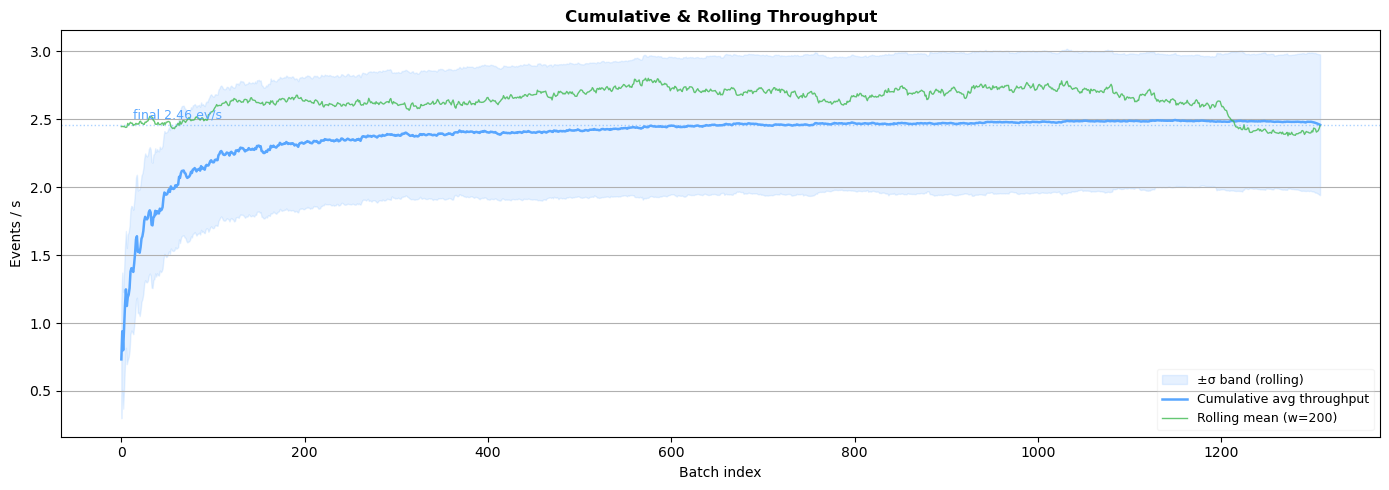

Saved plot1_throughput.png


/mnt/home/baburish/miniconda3/miniconda/envs/3pandelnet/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/home/baburish/miniconda3/miniconda/envs/3pandelnet/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


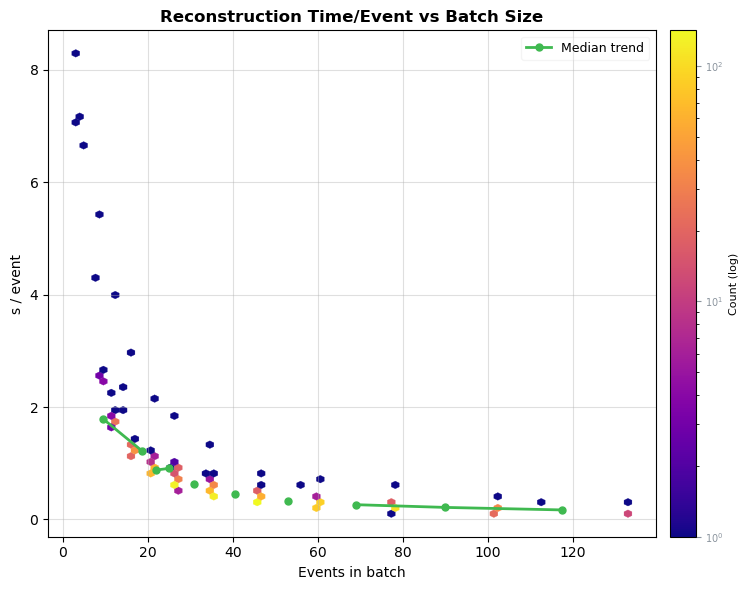

Saved plot2_tpe_vs_batchsize.png


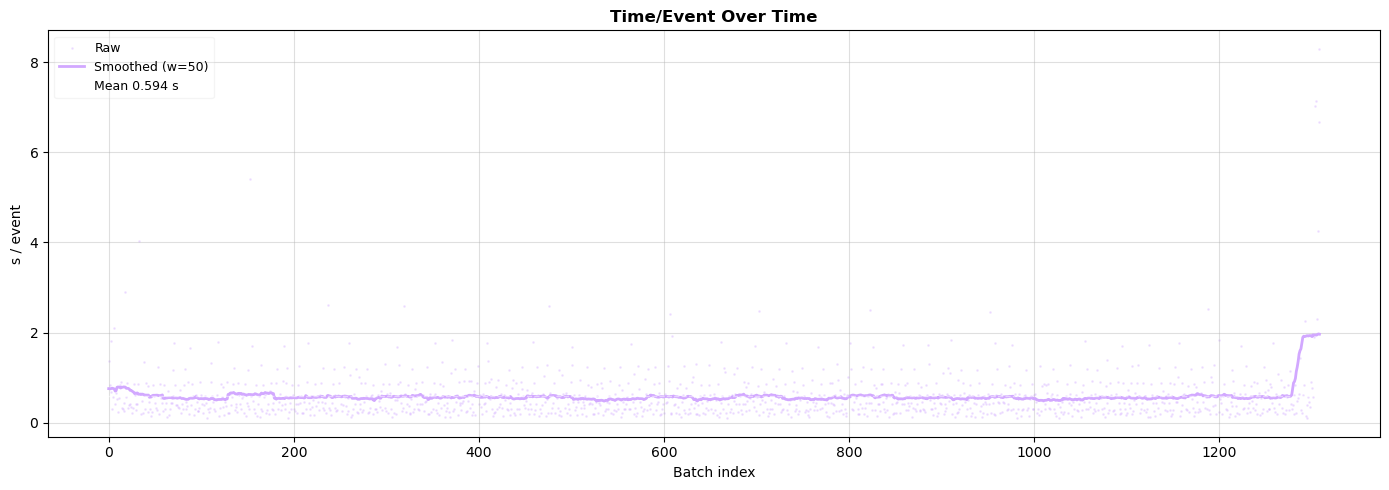

Saved plot3_tpe_over_time.png


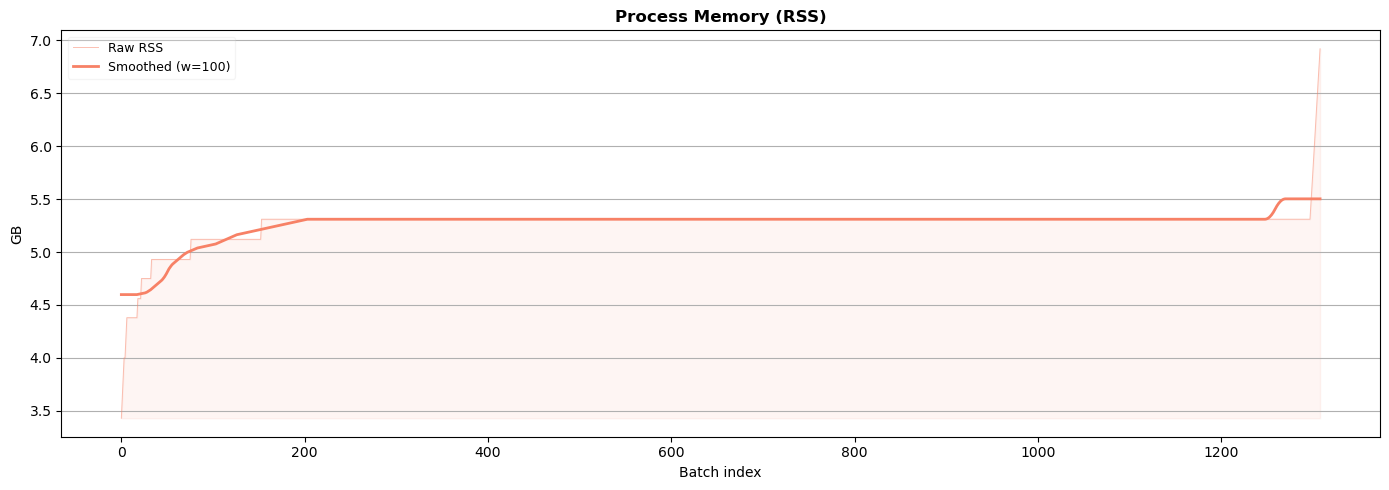

Saved plot4_rss.png


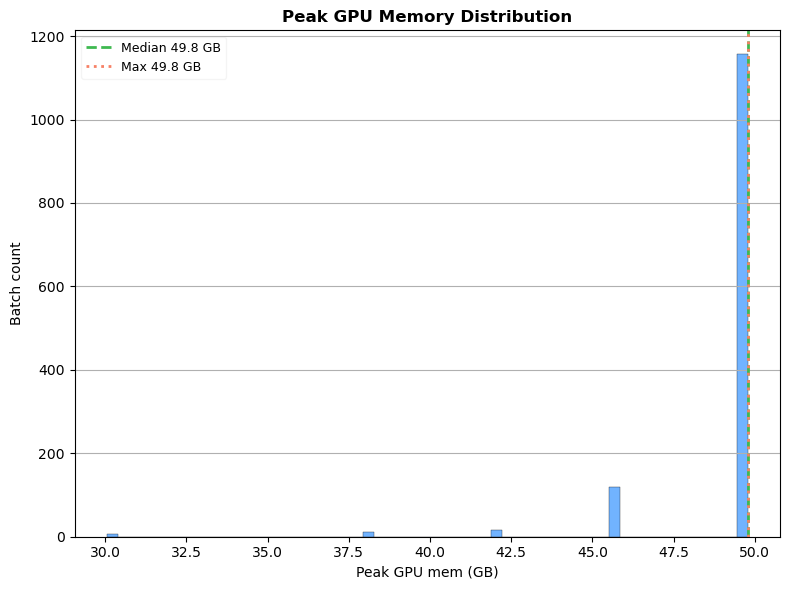

Saved plot5_gpu_hist.png


In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.ndimage import uniform_filter1d

log_path = "/mnt/scratch/baburish/TPN-training/final/TPN_God/reco-logs/batchreco-22645slurm_run0to1000.log"

# ── Parse ─────────────────────────────────────────────────────────────────────
n_events, times, rss, gpu = [], [], [], []
current = {}

with open(log_path) as f:
    for line in f:
        line = line.strip()
        m = re.match(r"Data shape:\s*\((\d+),", line)
        if m: current["n"] = int(m.group(1))
        m = re.match(r"Batch \d+ completed in ([\d.]+)s", line)
        if m: current["t"] = float(m.group(1))
        m = re.search(r"Process RSS:\s*([\d.]+)", line)
        if m: current["rss"] = float(m.group(1))
        m = re.search(r"peak\s*([\d.]+)", line)
        if m:
            current["gpu"] = float(m.group(1))
            if all(k in current for k in ("n", "t", "rss", "gpu")):
                n_events.append(current["n"])
                times.append(current["t"])
                rss.append(current["rss"])
                gpu.append(current["gpu"])
            current = {}

n, t, rss, gpu = map(np.array, [n_events, times, rss, gpu])
tpe        = t / n
throughput = n / t
b          = np.arange(len(n))
cum_thr    = np.cumsum(n) / np.cumsum(t)
smooth_tpe = uniform_filter1d(tpe, size=50)

# ── Shared style ──────────────────────────────────────────────────────────────
DARK  = "#0d1117"
PANEL = "#161b22"
GRID  = "#21262d"
C1, C2, C3, C4 = "#58a6ff", "#3fb950", "#f78166", "#d2a8ff"

# RC = {
#     "figure.facecolor": DARK, "axes.facecolor": PANEL,
#     "axes.edgecolor":   GRID, "axes.labelcolor": "#c9d1d9",
#     "axes.titlecolor":  "#e6edf3", "xtick.color": "#8b949e",
#     "ytick.color":      "#8b949e", "grid.color": GRID,
#     "grid.linewidth":   0.6, "text.color": "#c9d1d9",
#     "font.family":      "monospace", "axes.titlesize": 11,
#     "axes.labelsize":   9,
# }
# plt.rcParams.update(RC)

def savefig(fig, name):
    fig.savefig(name, dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()
    print(f"Saved {name}")

# ═══════════════════════════════════════════════════════════════════════════════
# Plot 1 — Cumulative & Rolling Throughput
# ═══════════════════════════════════════════════════════════════════════════════
win = 200
roll_mean = uniform_filter1d(throughput, size=win)
roll_std  = np.array([throughput[max(0,i-win//2):i+win//2].std()
                      for i in range(len(throughput))])

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(b, cum_thr - roll_std*0.3, cum_thr + roll_std*0.3,
                color=C1, alpha=0.15, label="±σ band (rolling)")
ax.plot(b, cum_thr,   color=C1, lw=1.8, label="Cumulative avg throughput")
ax.plot(b, roll_mean, color=C2, lw=1.0, alpha=0.8, label=f"Rolling mean (w={win})")
ax.axhline(cum_thr[-1], color=C1, ls=":", lw=1, alpha=0.5)
ax.text(len(b)*0.01, cum_thr[-1]*1.02,
        f"final {cum_thr[-1]:.2f} ev/s", color=C1, fontsize=9)
ax.set_xlabel("Batch index")
ax.set_ylabel("Events / s")
ax.set_title("Cumulative & Rolling Throughput", fontweight="bold")
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(True, axis="y")
fig.tight_layout()
savefig(fig, "plot1_throughput.png")

# ═══════════════════════════════════════════════════════════════════════════════
# Plot 2 — Time/Event vs Batch Size (hexbin + median trend)
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(n, tpe, gridsize=70, cmap="plasma",
               norm=LogNorm(), mincnt=1, linewidths=0.2)
bins  = np.percentile(n, np.linspace(0, 100, 20))
meds  = [np.median(tpe[(n >= bins[i]) & (n < bins[i+1])])
         for i in range(len(bins)-1)]
bmids = 0.5*(bins[:-1] + bins[1:])
ax.plot(bmids, meds, color=C2, lw=2, marker="o", ms=5, label="Median trend")
cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("Count (log)", fontsize=8)
cb.ax.yaxis.set_tick_params(color="#8b949e")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="#8b949e", fontsize=7)
ax.set_xlabel("Events in batch")
ax.set_ylabel("s / event")
ax.set_title("Reconstruction Time/Event vs Batch Size", fontweight="bold")
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(True, alpha=0.4)
fig.tight_layout()
savefig(fig, "plot2_tpe_vs_batchsize.png")

# ═══════════════════════════════════════════════════════════════════════════════
# Plot 3 — Time/Event Over Time
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(b, tpe, s=1, color=C4, alpha=0.25, rasterized=True, label="Raw")
ax.plot(b, smooth_tpe, color=C4, lw=2, label="Smoothed (w=50)")
ax.axhline(tpe.mean(), color="white", ls="--", lw=1, alpha=0.5,
           label=f"Mean {tpe.mean():.3f} s")
ax.set_xlabel("Batch index")
ax.set_ylabel("s / event")
ax.set_title("Time/Event Over Time", fontweight="bold")
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(True, alpha=0.4)
fig.tight_layout()
savefig(fig, "plot3_tpe_over_time.png")

# ═══════════════════════════════════════════════════════════════════════════════
# Plot 4 — Process Memory (RSS)
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(b, rss, color=C3, lw=0.7, alpha=0.5, label="Raw RSS")
ax.plot(b, uniform_filter1d(rss, size=100), color=C3, lw=2, label="Smoothed (w=100)")
ax.fill_between(b, rss.min(), rss, alpha=0.08, color=C3)
ax.set_xlabel("Batch index")
ax.set_ylabel("GB")
ax.set_title("Process Memory (RSS)", fontweight="bold")
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(True, axis="y")
fig.tight_layout()
savefig(fig, "plot4_rss.png")

# ═══════════════════════════════════════════════════════════════════════════════
# Plot 5 — Peak GPU Memory Distribution
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(gpu, bins=60, color=C1, edgecolor=DARK, linewidth=0.3, alpha=0.85)
ax.axvline(np.median(gpu), color=C2, lw=2, ls="--",
           label=f"Median {np.median(gpu):.1f} GB")
ax.axvline(gpu.max(), color=C3, lw=2, ls=":",
           label=f"Max {gpu.max():.1f} GB")
ax.set_xlabel("Peak GPU mem (GB)")
ax.set_ylabel("Batch count")
ax.set_title("Peak GPU Memory Distribution", fontweight="bold")
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(True, axis="y")
fig.tight_layout()
savefig(fig, "plot5_gpu_hist.png")

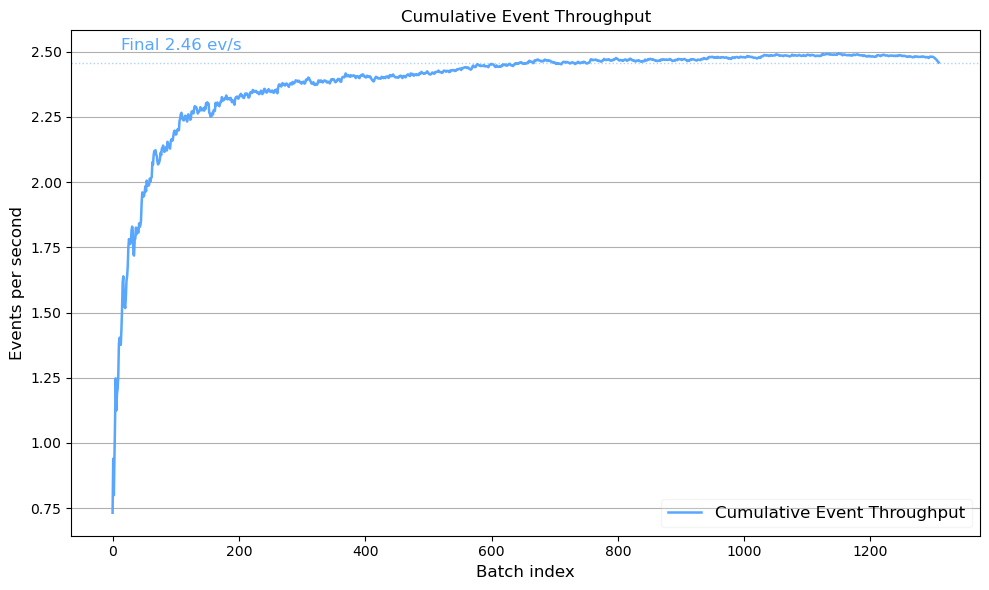

In [14]:
win = 200
roll_mean = uniform_filter1d(throughput, size=win)
roll_std  = np.array([throughput[max(0,i-win//2):i+win//2].std()
                      for i in range(len(throughput))])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(b, cum_thr,   color=C1, lw=1.8, label="Cumulative Event Throughput")
ax.axhline(cum_thr[-1], color=C1, ls=":", lw=1, alpha=0.5)
ax.text(len(b)*0.01, cum_thr[-1]*1.02,
        f"Final {cum_thr[-1]:.2f} ev/s", color=C1, fontsize=12)
ax.set_xlabel("Batch index", fontsize=12)
ax.set_ylabel("Events per second", fontsize=12)
ax.set_title("Cumulative Event Throughput")
ax.legend(fontsize=12, framealpha=0.2)
ax.grid(True, axis="y")
fig.tight_layout()
# savefig(fig, "plot1_throughput.png")

/mnt/home/baburish/miniconda3/miniconda/envs/3pandelnet/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/home/baburish/miniconda3/miniconda/envs/3pandelnet/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3353507/2053562406.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12, framealpha=0.2)


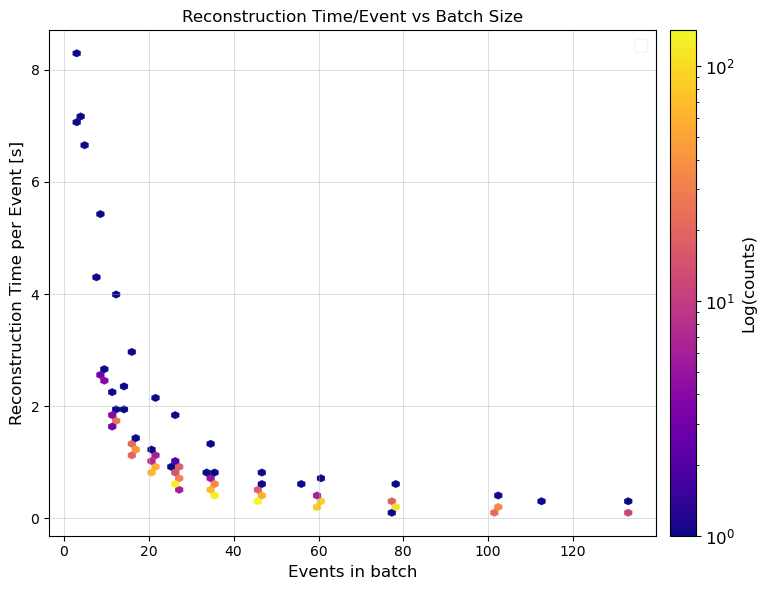

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(n, tpe, gridsize=70, cmap="plasma",
               norm=LogNorm(), mincnt=1, linewidths=0.2)
bins  = np.percentile(n, np.linspace(0, 100, 20))
meds  = [np.median(tpe[(n >= bins[i]) & (n < bins[i+1])])
         for i in range(len(bins)-1)]
bmids = 0.5*(bins[:-1] + bins[1:])
# ax.plot(bmids, meds, color=C2, lw=2, marker="o", ms=5, label="Median trend")
cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("Log(counts)", fontsize=12)
cb.ax.yaxis.set_tick_params(color='black')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='black', fontsize=12)
ax.set_xlabel("Events in batch", fontsize=12)
ax.set_ylabel("Reconstruction Time per Event [s]", fontsize=12)
ax.set_title("Reconstruction Time/Event vs Batch Size", fontsize=12)
ax.legend(fontsize=12, framealpha=0.2)
ax.grid(True, alpha=0.4)
fig.tight_layout()
# savefig(fig, "plot2_tpe_vs_batchsize.png")


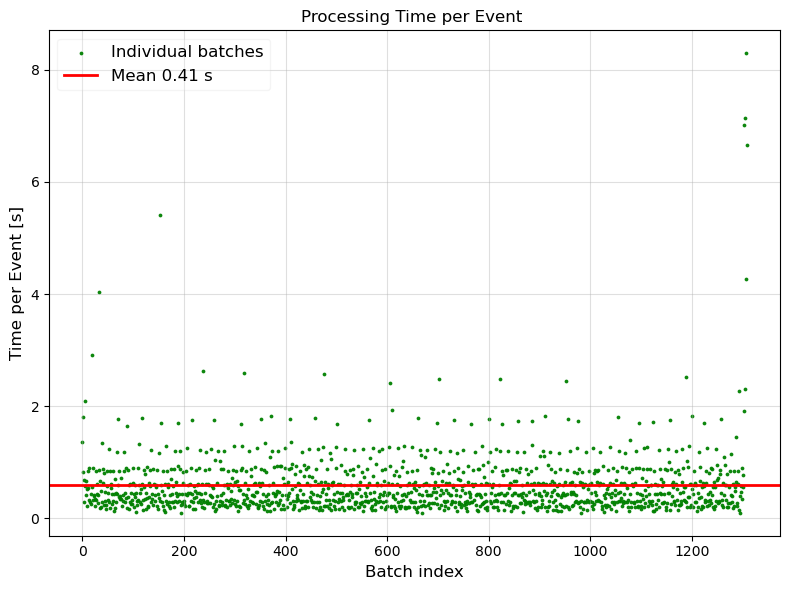

In [42]:
# ═══════════════════════════════════════════════════════════════════════════════
# Plot 3 — Time/Event Over Time
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(b, tpe, s=3, color='green', alpha=0.9, rasterized=True, label="Individual batches")
# ax.plot(b, smooth_tpe, color=C4, lw=2, label="Smoothed (w=50)")
ax.axhline(tpe.mean(), color="red", ls="-", lw=2, alpha=1,
           label=f"Mean {0.4095711:.2f} s")
ax.set_xlabel("Batch index", fontsize=12)
ax.set_ylabel("Time per Event [s]", fontsize=12)
ax.set_title("Processing Time per Event ", fontsize=12)
ax.legend(fontsize=12, framealpha=0.2)
ax.grid(True, alpha=0.4)
fig.tight_layout()


Batches  : 229
Events   : 2294
Total t  : 1.490 h  (5363.2 s)
s/event  : 3.7933 ± 2.6235
Avg thr  : 0.459 ev/s


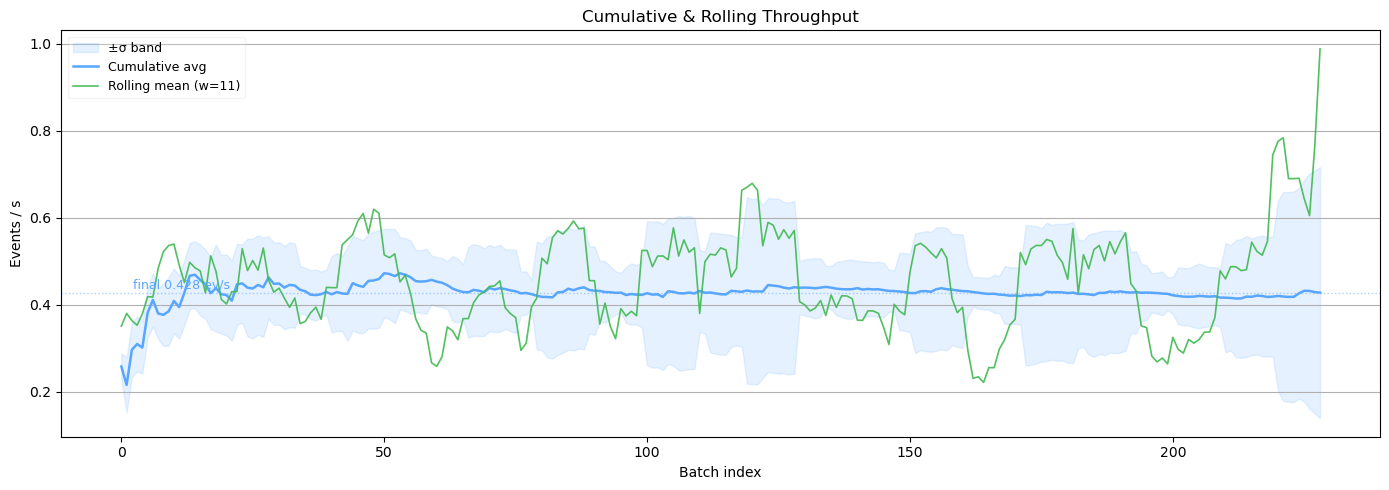

Saved plot1_throughput.png


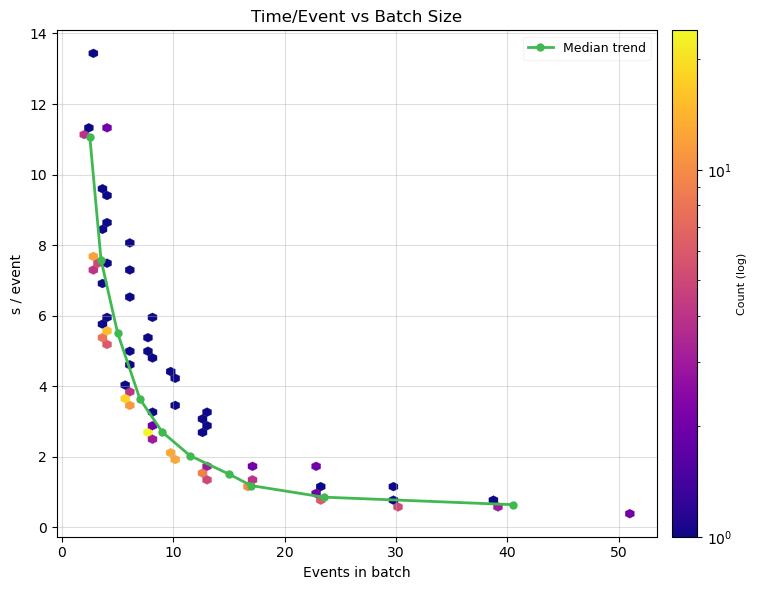

Saved plot2_tpe_vs_batchsize.png


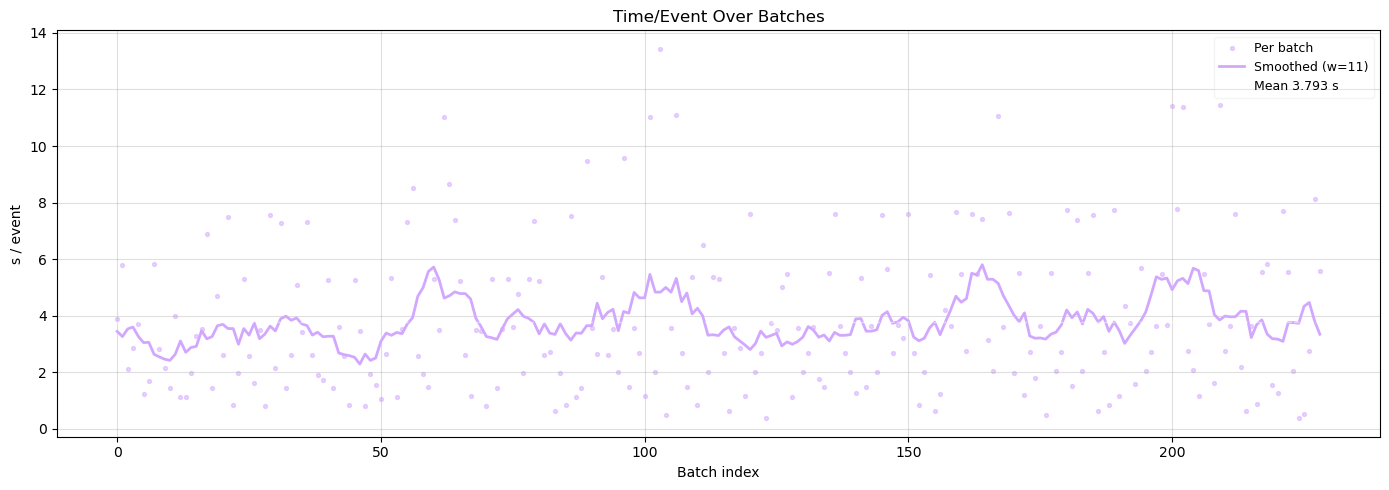

Saved plot3_tpe_over_time.png


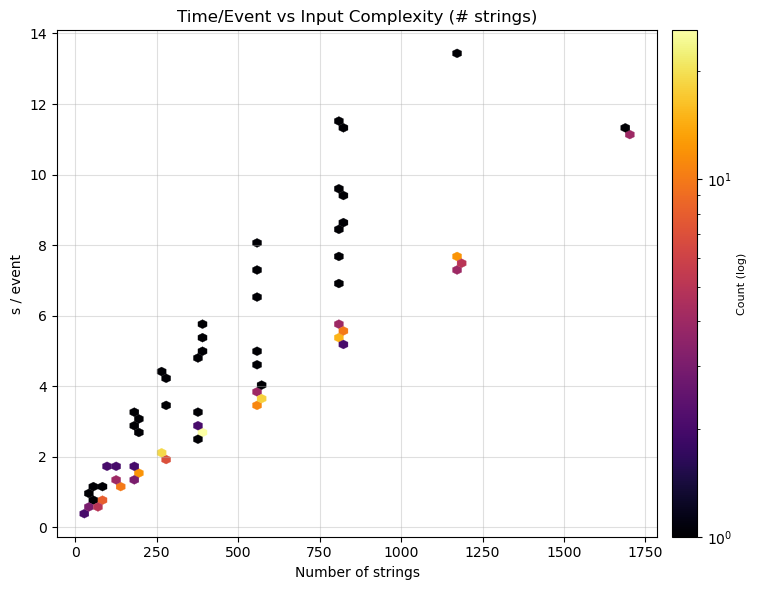

Saved plot4_tpe_vs_strings.png


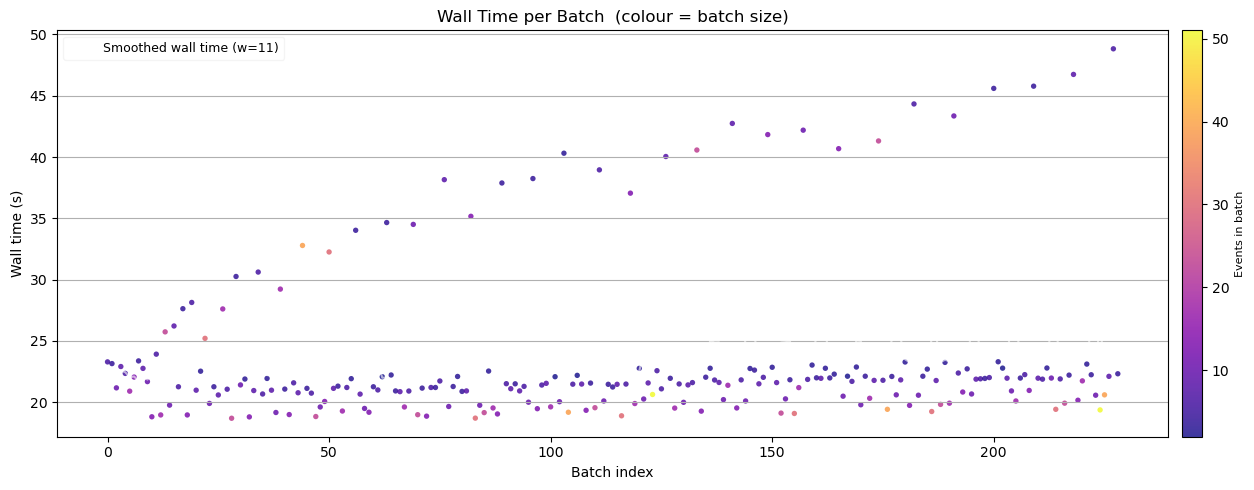

Saved plot5_walltime.png


In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.ndimage import uniform_filter1d

log_path = "/mnt/scratch/baburish/TPN-training/final/TPN_God/reco-logs/22644_1000_to_2000.log"  # <-- update this

# ── Parse ─────────────────────────────────────────────────────────────────────
n_events, times, n_strings = [], [], []
current = {}

with open(log_path) as f:
    for line in f:
        line = line.strip()
        m = re.match(r"Data shape:\s*\((\d+),\s*(\d+),", line)
        if m:
            current["n"]  = int(m.group(1))
            current["ns"] = int(m.group(2))
        m = re.match(r"Batch \d+ completed in ([\d.]+)s", line)
        if m:
            current["t"] = float(m.group(1))
            if all(k in current for k in ("n", "ns", "t")):
                n_events.append(current["n"])
                n_strings.append(current["ns"])
                times.append(current["t"])
            current = {}

n, ns, t = map(np.array, [n_events, n_strings, times])
tpe       = t / n
throughput = n / t
b          = np.arange(len(n))
cum_thr    = np.cumsum(n) / np.cumsum(t)
smooth_tpe = uniform_filter1d(tpe, size=max(3, len(n)//20))

print(f"Batches  : {len(n)}")
print(f"Events   : {n.sum()}")
print(f"Total t  : {t.sum()/3600:.3f} h  ({t.sum():.1f} s)")
print(f"s/event  : {tpe.mean():.4f} ± {tpe.std():.4f}")
print(f"Avg thr  : {throughput.mean():.3f} ev/s")

# ── Style ─────────────────────────────────────────────────────────────────────
DARK  = "#0d1117"
PANEL = "#161b22"
GRID  = "#21262d"
C1, C2, C3, C4 = "#58a6ff", "#3fb950", "#f78166", "#d2a8ff"

# plt.rcParams.update({
#     "figure.facecolor": DARK,  "axes.facecolor":  PANEL,
#     "axes.edgecolor":   GRID,  "axes.labelcolor": "#c9d1d9",
#     "axes.titlecolor":  "#e6edf3", "xtick.color": "#8b949e",
#     "ytick.color":      "#8b949e", "grid.color":  GRID,
#     "grid.linewidth":   0.6,   "text.color":      "#c9d1d9",
#     "font.family":      "monospace", "axes.titlesize": 11,
#     "axes.labelsize":   9,
# })

def savefig(fig, name):
    fig.savefig(name, dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()
    print(f"Saved {name}")

# ═══════════════════════════════════════════════════════════════════════════════
# Plot 1 — Cumulative & Rolling Throughput
# ═══════════════════════════════════════════════════════════════════════════════
win = max(3, len(n) // 20)
roll_mean = uniform_filter1d(throughput, size=win)
roll_std  = np.array([throughput[max(0,i-win//2):i+win//2].std()
                      for i in range(len(throughput))])

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(b, cum_thr - roll_std*0.3, cum_thr + roll_std*0.3,
                color=C1, alpha=0.15, label="±σ band")
ax.plot(b, cum_thr,   color=C1, lw=1.8, label="Cumulative avg")
ax.plot(b, roll_mean, color=C2, lw=1.2, alpha=0.9, label=f"Rolling mean (w={win})")
ax.axhline(cum_thr[-1], color=C1, ls=":", lw=1, alpha=0.5)
ax.text(len(b)*0.01, cum_thr[-1]*1.02,
        f"final {cum_thr[-1]:.3f} ev/s", color=C1, fontsize=9)
ax.set(xlabel="Batch index", ylabel="Events / s",
       title="Cumulative & Rolling Throughput")
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(True, axis="y")
fig.tight_layout()
savefig(fig, "plot1_throughput.png")

# ═══════════════════════════════════════════════════════════════════════════════
# Plot 2 — Time/Event vs Batch Size
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))

# for small datasets fall back to scatter; hexbin needs enough points
if len(n) > 200:
    hb = ax.hexbin(n, tpe, gridsize=60, cmap="plasma",
                   norm=LogNorm(), mincnt=1, linewidths=0.2)
    fig.colorbar(hb, ax=ax, pad=0.02).set_label("Count (log)", fontsize=8)
else:
    ax.scatter(n, tpe, color=C4, s=30, alpha=0.7, edgecolors="none")

# median trend (need enough unique bins)
pct_edges = np.percentile(n, np.linspace(0, 100, min(20, len(n)//2 + 1)))
if len(np.unique(pct_edges)) > 2:
    meds, bmids = [], []
    for i in range(len(pct_edges)-1):
        mask = (n >= pct_edges[i]) & (n < pct_edges[i+1])
        if mask.sum() > 0:
            meds.append(np.median(tpe[mask]))
            bmids.append(0.5*(pct_edges[i] + pct_edges[i+1]))
    ax.plot(bmids, meds, color=C2, lw=2, marker="o", ms=5, label="Median trend")

ax.set(xlabel="Events in batch", ylabel="s / event",
       title="Time/Event vs Batch Size")
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(True, alpha=0.4)
fig.tight_layout()
savefig(fig, "plot2_tpe_vs_batchsize.png")

# ═══════════════════════════════════════════════════════════════════════════════
# Plot 3 — Time/Event over Batches
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(b, tpe, s=8, color=C4, alpha=0.5, rasterized=True, label="Per batch")
ax.plot(b, smooth_tpe, color=C4, lw=2, label=f"Smoothed (w={win})")
ax.axhline(tpe.mean(), color="white", ls="--", lw=1, alpha=0.5,
           label=f"Mean {tpe.mean():.3f} s")
ax.set(xlabel="Batch index", ylabel="s / event", title="Time/Event Over Batches")
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(True, alpha=0.4)
fig.tight_layout()
savefig(fig, "plot3_tpe_over_time.png")

# ═══════════════════════════════════════════════════════════════════════════════
# Plot 4 — Time/Event vs Number of Strings (input complexity)
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))

if len(n) > 200:
    hb = ax.hexbin(ns, tpe, gridsize=60, cmap="inferno",
                   norm=LogNorm(), mincnt=1, linewidths=0.2)
    fig.colorbar(hb, ax=ax, pad=0.02).set_label("Count (log)", fontsize=8)
else:
    sc = ax.scatter(ns, tpe, c=n, cmap="plasma", s=40, alpha=0.8,
                    edgecolors="none")
    fig.colorbar(sc, ax=ax, pad=0.02).set_label("Events in batch", fontsize=8)

ax.set(xlabel="Number of strings", ylabel="s / event",
       title="Time/Event vs Input Complexity (# strings)")
ax.grid(True, alpha=0.4)
fig.tight_layout()
savefig(fig, "plot4_tpe_vs_strings.png")

# ═══════════════════════════════════════════════════════════════════════════════
# Plot 5 — Batch time vs batch index, coloured by batch size
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))
sc = ax.scatter(b, t, c=n, cmap="plasma", s=15, alpha=0.8,
                edgecolors="none", rasterized=True)
ax.plot(b, uniform_filter1d(t, size=win), color="white", lw=1.5,
        alpha=0.6, label=f"Smoothed wall time (w={win})")
fig.colorbar(sc, ax=ax, pad=0.01).set_label("Events in batch", fontsize=8)
ax.set(xlabel="Batch index", ylabel="Wall time (s)",
       title="Wall Time per Batch  (colour = batch size)")
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(True, axis="y")
fig.tight_layout()
savefig(fig, "plot5_walltime.png")

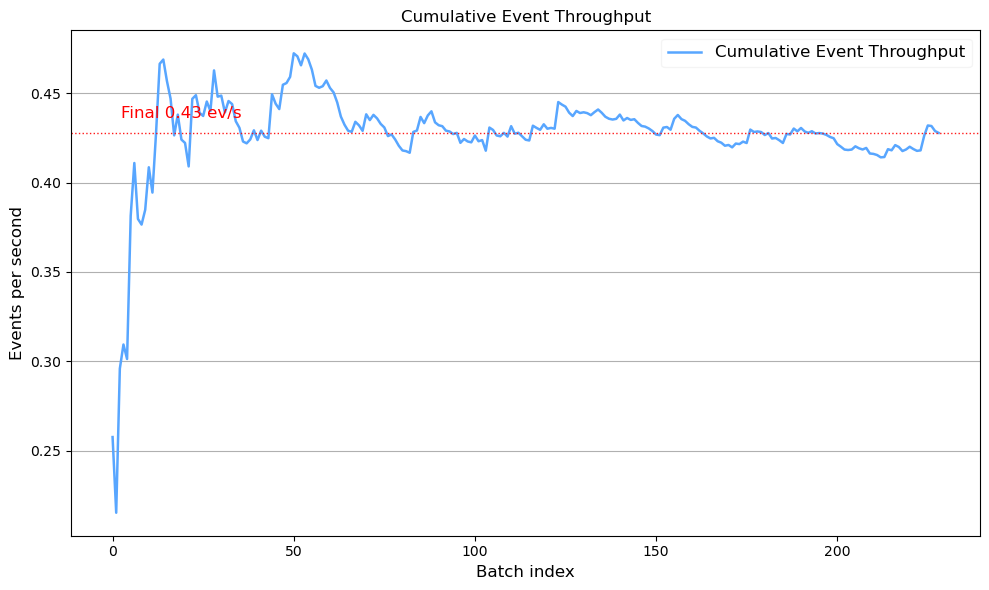

In [5]:
win = 200
roll_mean = uniform_filter1d(throughput, size=win)
roll_std  = np.array([throughput[max(0,i-win//2):i+win//2].std()
                      for i in range(len(throughput))])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(b, cum_thr,   color=C1, lw=1.8, label="Cumulative Event Throughput")
ax.axhline(cum_thr[-1], color='red', ls=":", lw=1, alpha=0.9)
ax.text(len(b)*0.01, cum_thr[-1]*1.02,
        f"Final {cum_thr[-1]:.2f} ev/s", color='red', fontsize=12)
ax.set_xlabel("Batch index", fontsize=12)
ax.set_ylabel("Events per second", fontsize=12)
ax.set_title("Cumulative Event Throughput")
ax.legend(fontsize=12, framealpha=0.2)
ax.grid(True, axis="y")
fig.tight_layout()
# savefig(fig, "plot1_throughput.png")

/mnt/home/baburish/miniconda3/miniconda/envs/3pandelnet/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/home/baburish/miniconda3/miniconda/envs/3pandelnet/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3434180/2053562406.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12, framealpha=0.2)


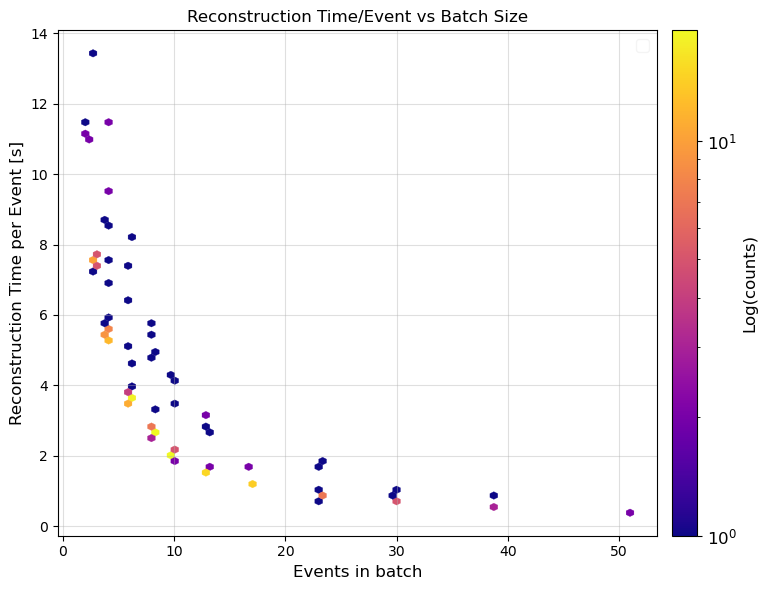

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(n, tpe, gridsize=70, cmap="plasma",
               norm=LogNorm(), mincnt=1, linewidths=0.2)
bins  = np.percentile(n, np.linspace(0, 100, 20))
meds  = [np.median(tpe[(n >= bins[i]) & (n < bins[i+1])])
         for i in range(len(bins)-1)]
bmids = 0.5*(bins[:-1] + bins[1:])
# ax.plot(bmids, meds, color=C2, lw=2, marker="o", ms=5, label="Median trend")
cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("Log(counts)", fontsize=12)
cb.ax.yaxis.set_tick_params(color='black')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='black', fontsize=12)
ax.set_xlabel("Events in batch", fontsize=12)
ax.set_ylabel("Reconstruction Time per Event [s]", fontsize=12)
ax.set_title("Reconstruction Time/Event vs Batch Size", fontsize=12)
ax.legend(fontsize=12, framealpha=0.2)
ax.grid(True, alpha=0.4)
fig.tight_layout()
# savefig(fig, "plot2_tpe_vs_batchsize.png")


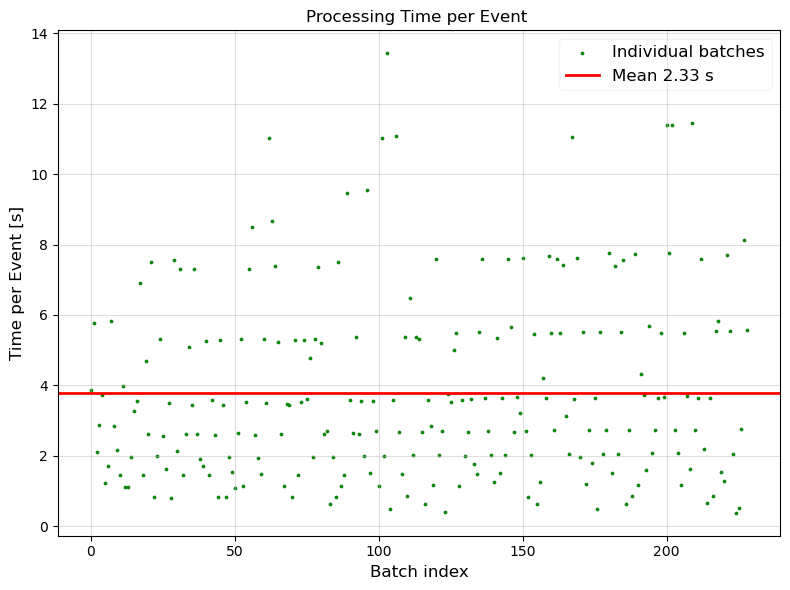

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# Plot 3 — Time/Event Over Time
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(b, tpe, s=3, color='green', alpha=0.9, rasterized=True, label="Individual batches")
# ax.plot(b, smooth_tpe, color=C4, lw=2, label="Smoothed (w=50)")
ax.axhline(tpe.mean(), color="red", ls="-", lw=2, alpha=1,
           label=f"Mean {2.33:.2f} s")
ax.set_xlabel("Batch index", fontsize=12)
ax.set_ylabel("Time per Event [s]", fontsize=12)
ax.set_title("Processing Time per Event ", fontsize=12)
ax.legend(fontsize=12, framealpha=0.2)
ax.grid(True, alpha=0.4)
fig.tight_layout()
